读取排放文件: pollutant_emission.bin
数据范围: 0.00e+00 ~ 8.95e+06
警告: 找不到地形掩码文件 ./ETOPO/topo.bin


/tmp/ipykernel_603211/3013423583.py:91: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) SimHei.
  plt.tight_layout()
/tmp/ipykernel_603211/3013423583.py:91: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
/tmp/ipykernel_603211/3013423583.py:91: UserWarning: Glyph 185 (\N{SUPERSCRIPT ONE}) missing from font(s) SimHei.
  plt.tight_layout()
/tmp/ipykernel_603211/3013423583.py:95: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) SimHei.
  plt.savefig(out_fig, dpi=300)
/tmp/ipykernel_603211/3013423583.py:95: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig(out_fig, dpi=300)
/tmp/ipykernel_603211/3013423583.py:95: UserWarning: Glyph 185 (\N{SUPERSCRIPT ONE}) missing from font(s) SimHei.
  plt.savefig(out_fig, dpi=300)


图像已保存: pollutant_emission_ETOPO_mask.png


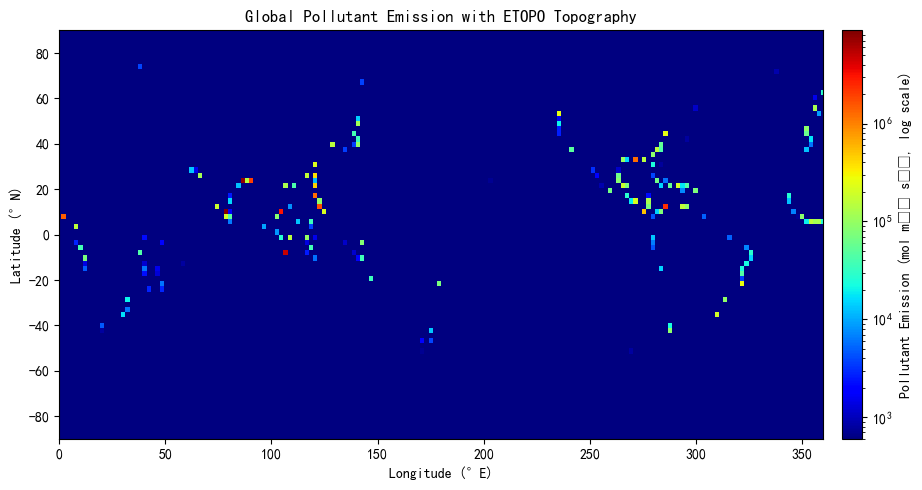

In [5]:
#!/usr/bin/env python3
"""
可视化 MITgcm 污染物排放源文件 (pollutant_emission.bin)
叠加 ETOPO 地形掩码 (无翻转版)
Author: 汪锐
"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LogNorm


def visualize_pollutant_emission_with_mask(
        emission_file='pollutant_emission.bin',
        mask_file='./input/ETOPO/topo.bin',
        nx=180, ny=80,
        log_scale=True,
        cmap='jet',
        save_fig=True):
    """
    可视化污染物排放文件并叠加地形掩码 (不翻转版本)
    
    参数:
        emission_file : str  排放场文件 (.bin)
        mask_file     : str  地形文件 (.bin)
        nx, ny        : int  网格大小
        log_scale     : bool 是否使用对数色标
        cmap          : str  色标
        save_fig      : bool 是否保存图像
    """

    if not os.path.exists(emission_file):
        print(f"错误: 找不到文件 {emission_file}")
        return

    # ===== 读取排放数据 =====
    data = np.fromfile(emission_file, dtype='>f4', count=nx * ny)
    data = data.reshape((ny, nx))
    print(f"读取排放文件: {emission_file}")
    print(f"数据范围: {np.nanmin(data):.2e} ~ {np.nanmax(data):.2e}")

    # ===== 读取地形掩码 =====
    if not os.path.exists(mask_file):
        print(f"警告: 找不到地形掩码文件 {mask_file}")
        mask_data = None
    else:
        mask_data = np.fromfile(mask_file, dtype='>f4', count=nx * ny)
        mask_data = mask_data.reshape((ny, nx))
        print(f"读取地形掩码: {mask_file}")
        print(f"地形范围: {mask_data.min():.1f} ~ {mask_data.max():.1f}")

        # 无需翻转，保持与 ETOPO 相同方向
        ocean_mask = mask_data < 0

    # ===== 经纬度坐标 =====
    lon = np.linspace(0, 360, nx)
    lat = np.linspace(-90,90, ny)

    # ===== 绘图 =====
    fig, ax = plt.subplots(figsize=(10, 5))

    if log_scale:
        vmin = np.nanmax([np.nanmin(data[data > 0]), 1e-10])
        norm = LogNorm(vmin=vmin, vmax=np.nanmax(data))
        label = 'Pollutant Emission (mol m⁻² s⁻¹, log scale)'
    else:
        norm = None
        label = 'Pollutant Emission (mol m⁻² s⁻¹)'

    pcm = ax.pcolormesh(lon, lat, np.clip(data, 1e-12, None),
                        cmap=cmap, shading='auto', norm=norm)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label(label)

    # ===== 绘制掩码 =====
    if mask_data is not None:
        land = np.ma.masked_where(mask_data < 0, mask_data)
        ax.pcolormesh(lon, lat, land, shading='auto',
                      cmap='Greys', alpha=0.4, vmin=-5000, vmax=5000)
        print("已叠加陆地区域掩码")

    # ===== 图形修饰 =====
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    ax.set_xlim(0, 360)
    ax.set_ylim(-90, 90)
    ax.set_title('Global Pollutant Emission with ETOPO Topography')

    plt.tight_layout()

    if save_fig:
        out_fig = emission_file.replace('.bin', '_ETOPO_mask.png')
        plt.savefig(out_fig, dpi=300)
        print(f"图像已保存: {out_fig}")

    plt.show()


if __name__ == "__main__":
    visualize_pollutant_emission_with_mask(
        emission_file='pollutant_emission.bin',
        mask_file='./ETOPO/topo.bin',
        nx=180, ny=80,
        log_scale=True
    )
